## <font color="royalblue">**Procesamiento de lenguaje natural (NLP)**</font>
### <font color="royalblue">**Extracción de habilidades (skills)**</font>
En esta archivo se definen todos los pasos para extraer habilidades solicitadas (skills), de las descripciones de ofertas de empleo en Data Analyst para Barcelona.

- Paso 1: Preprocesamiento con spaCy para limpiar y lematizar  
- Paso 2: TF-IDF para una primera representación 
- Paso 3: Topic modeling con:  
            - Paso 3A. LDA (Latent Dirichlet Allocation)  
            - Paso 3B. BERTopic  
- Paso 4: Extracción de habilidades con diccionarios + spaCy  
- Paso 5: Clasificación o clustering  
- Paso 6: Extraer skills usando spaCy para mejorar la detección.
- Paso 7: Usar embeddings para detectar skills emergentes con:  
            - Paso 7A. spaCy  
            - Paso 7B. MiniLM

- Finalmente se exportan en archivo .csv los resultados para continuar con NLP
 


In [ ]:
import pandas as pd
import re
import numpy as np
from collections import Counter
import spacy
from langdetect import detect
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import matplotlib.pyplot as plt
import seaborn as sns
from spacy.matcher import PhraseMatcher
from sklearn.metrics.pairwise import cosine_similarity

# Cargar los modelos de lenguaje para español, inglés, catalan y francés.
nlp_es = spacy.load("es_core_news_md")
nlp_en = spacy.load("en_core_web_md")
nlp_ca = spacy.load("ca_core_news_md")
nlp_fr = spacy.load("fr_core_news_md")


In [ ]:
# Cargar df de los portales de empleo
df_Adzuna = pd.read_csv("df_Adzuna_clean.csv")
df_Indeed = pd.read_csv("df_Indeed_clean.csv")
df_LinkedIn = pd.read_csv("df_LinkedIn_clean.csv")

In [82]:
# Función para detectar el idioma de un texto
def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "unknown"

In [83]:
modelos = { "es": nlp_es, "ca": nlp_ca, "en": nlp_en, "fr": nlp_fr}

### Paso 1: Preprocesamiento con spaCy
Función de preprocesamiento con spaCy (por idioma).  
Esta función: detecta idioma, usa el modelo correcto, tokeniza, lematiza, elimina stopwords, elimina puntuación, devuelve un texto limpio

In [ ]:
# Función para preprocesar un texto con Spacy
def preprocesar_spacy(texto):
    if texto is None:
        return None
    
    idioma = detectar_idioma(texto)

    if idioma == "es":
        doc = nlp_es(texto)
    elif idioma == "en":
        doc = nlp_en(texto)
    elif idioma == "ca":
        doc = nlp_ca(texto)
    elif idioma == "fr":
        doc = nlp_fr(texto)
    else:
        return texto.lower()

    tokens_limpios = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
    ]

    return " ".join(tokens_limpios)


Para el analisis NLP se descartarán las ofertas con descripciones truncadas y vacias

In [95]:
# df Adzuna sin descripciones truncadas
df_Adzuna = df_Adzuna[df_Adzuna["es_truncada"] == False]

# df Indeed con descripciones vacias
df_Indeed = df_Indeed[df_Indeed["descripcion"].notna()]


In [ ]:
# Aplicar preprocesamiento con Spacy a las descripciones
df_Adzuna["descripcion_nlp"] = df_Adzuna["descripcion"].apply(preprocesar_spacy)
df_LinkedIn["descripcion_nlp"] = df_LinkedIn["descripcion"].apply(preprocesar_spacy)
# Aplicar lambda: aplica la función si es notnull, sino devuelve NaN
df_Indeed['descripcion_nlp'] = df_Indeed['descripcion'].apply(preprocesar_spacy)


#### Paso 2: Vectorización TF‑IDF por portal 
Se busca vectorizar con TF‑IDF, devolver la matriz TF‑IDF y el vectorizador.


- Paso 2A: Vectorización por portal (TF-IDF)  
español e inglés, por separado, con spaCy ya aplicado.

- Paso 2B: Vectorización global  
unir todos los portales, TF-IDF global, análisis comparativo

- Paso 2C: Preparación para topic modeling
matrices por portal, matrices globales, exclusión opcional de truncadas

In [ ]:
#Funcion para preparación previa (asegurar texto válido)
def preparar_texto(df, columna="descripcion_nlp"):
    df = df.copy()
    df[columna] = df[columna].fillna("")
    df[columna] = df[columna].astype(str)
    df["descripcion_vacia"] = df[columna].str.strip() == ""
    return df


In [97]:
df_Adzuna = preparar_texto(df_Adzuna)
df_LinkedIn = preparar_texto(df_LinkedIn)
df_Indeed = preparar_texto(df_Indeed)


In [99]:
# Función TF‑IDF por portal
def vectorizar_portal(df, columna="descripcion_nlp", 
                    max_features=5000, 
                    ngram_range=(1,2),
                    excluir_vacias=True):
    
    # Filtrar si se desea excluir descripciones vacías
    if excluir_vacias:
        df_filtrado = df[df[columna].str.strip() != ""].copy()
    else:
        df_filtrado = df.copy()
    
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range
    )
    
    X = vectorizer.fit_transform(df_filtrado[columna])
    
    return X, vectorizer, df_filtrado


Para cada portal:  
X_portal → matriz TF‑IDF para:  
    - clustering,
    - topic modeling,
    - clasificación,
    - análisis de similitud.  
vect_portal → el vectorizador entrenado permite:  
    - ver vocabulario,
    - transformar nuevos textos,
    - comparar portales.  
df_portal_vec → el dataframe filtrado:  
    - sin descripciones vacías,
    - alineado con la matriz TF‑IDF.

In [101]:
X_adzuna, vect_adzuna, df_adzuna_vec = vectorizar_portal(df_Adzuna)
X_indeed, vect_indeed, df_indeed_vec = vectorizar_portal(df_Indeed)
X_linkedin, vect_linkedin, df_linkedin_vec = vectorizar_portal(df_LinkedIn)

In [102]:
# Ver top términos por frecuencia TF‑IDF
def top_terms(vectorizer, X, n=20):
    sums = X.sum(axis=0)
    terms = vectorizer.get_feature_names_out()
    data = []
    for col, term in enumerate(terms):
        data.append((term, sums[0, col]))
    ranking = sorted(data, key=lambda x: x[1], reverse=True)
    return ranking[:n]

top_terms(vect_adzuna, X_adzuna)


[('datum', np.float64(3.963277335544747)),
 ('team', np.float64(3.264482392974851)),
 ('data', np.float64(2.8429745147270182)),
 ('business', np.float64(2.7390728957154185)),
 ('work', np.float64(2.6029502061195022)),
 ('experience', np.float64(2.381214249330228)),
 ('product', np.float64(2.011620724929036)),
 ('project', np.float64(1.9329451385916854)),
 ('dato', np.float64(1.6615293829126063)),
 ('analysis', np.float64(1.6193928686582282)),
 ('driver', np.float64(1.5711264605383382)),
 ('process', np.float64(1.488791661350362)),
 ('ensure', np.float64(1.4592314324089435)),
 ('skill', np.float64(1.3854607566788504)),
 ('drive', np.float64(1.369741347773088)),
 ('marketing', np.float64(1.3588609109373064)),
 ('solution', np.float64(1.302045851446384)),
 ('support', np.float64(1.2819175264038039)),
 ('insight', np.float64(1.2576457479239846)),
 ('requirement', np.float64(1.253065500219581))]

#### Paso 3A: Topic Modeling por portal (LDA)
- funciona muy bien con TF‑IDF o CountVectorizer,
- permite comparar temas entre portales,
- es un excelente paso previo antes de usar BERTopic.  

Función general para aplicar LDA por portal
- Esta función: recibe la matriz TF‑IDF, recibe el vectorizador, entrena un modelo LDA.  
- devuelve: el modelo, los temas, las palabras clave por tema, el dataframe con el tema dominante, visualizaciones basicas.

In [ ]:
# Función para aplicar LDA
def aplicar_lda(X, vectorizer, n_topics=6, portal="portal"):
    
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch"
    )
    
    temas = lda.fit_transform(X)
    
    # Palabras clave por tema
    palabras = vectorizer.get_feature_names_out()
    top_palabras = {}
    
    for idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-15:][::-1]
        top_palabras[f"Tema_{idx}"] = [palabras[i] for i in top_indices]
    
    # Asignar tema dominante a cada oferta
    df_temas = pd.DataFrame(temas, columns=[f"Tema_{i}" for i in range(n_topics)])
    df_temas["tema_dominante"] = df_temas.idxmax(axis=1)
    
    print(f"\n📌 Temas detectados para {portal}:")
    for t, palabras in top_palabras.items():
        print(f"{t}: {', '.join(palabras)}")
    
    return lda, df_temas, top_palabras


In [103]:
# Aplicar LDA por portal

lda_adzuna, df_temas_adzuna, palabras_adzuna = aplicar_lda(
    X_adzuna, vect_adzuna, n_topics=6, portal="Adzuna")

lda_linkedin, df_temas_linkedin, palabras_linkedin = aplicar_lda(
    X_linkedin, vect_linkedin, n_topics=6, portal="LinkedIn")

lda_indeed, df_temas_indeed, palabras_indeed = aplicar_lda(
    X_indeed, vect_indeed, n_topics=6, portal="Indeed")



📌 Temas detectados para Adzuna:
Tema_0: prime, glovo prime, loyalty team, analyst loyalty, crm local, local growth, glovo, lever, successful, accountable, empresa glovo, glovo descripción, successful candidate, penetration, customer retention
Tema_1: datum, data, team, business, work, experience, product, analysis, drive, insight, support, process, skill, performance, analytic
Tema_2: driver, ride, mobility, team, experience, product, freenow, million, service, validation, app, city, document, connect, work
Tema_3: dato, equipo, experiencia, trabajar, scrm, digital, cliente, herramienta, analítico, análisis, producto, capacidad, schwarz, desarrollo, nivel
Tema_4: 3pl, amazon, tower, control tower, smadex, 3pl control, ad tech, actual, ef, eu, control, operational, external, shift, network
Tema_5: project, project delivery, finance, delivery, requirement, ensure, pet, management, rover, scope, ensure solution, solution meet, business, uat, stakeholder

📌 Temas detectados para LinkedIn:

- Interpretación de resultados
6 temas (número ajustable), cada tema con 15 palabras clave, un dataframe con el tema dominante por oferta
- Esto en teoria permite:
ver qué temas son más frecuentes en cada portal, comparar portales entre sí, detectar diferencias semánticas, identificar patrones 

<Axes: xlabel='tema_dominante'>

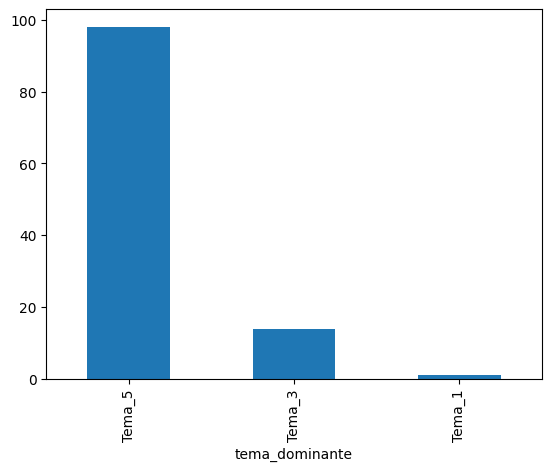

In [18]:
# Visualizar distribución de temas
df_temas_indeed["tema_dominante"].value_counts().plot(kind="bar")


####  Paso 3B: BERTopic por portal
- produce temas más coherentes
- maneja diferentes idiomas sin problemas
- usa embeddings que capturan significado
- genera visualizaciones interactivas
- permite comparar portales de forma profunda

In [ ]:
# Definir el modelo de embeddings
from sentence_transformers import SentenceTransformer
modelo_embeddings = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Este modelo: genera embeddings comparables entre idiomas, es rápido, funciona perfecto con BERTopic

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1170.50it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Función para preparar textos para BERTopic
def preparar_textos_para_bertopic(df, columna="descripcion_nlp"):
    df = df.copy()

    # Eliminar NaN
    df = df[df[columna].notnull()]
    # Convertir todo a string
    df[columna] = df[columna].astype(str)
    # Excluir vacías
    df = df[df[columna].str.strip() != ""]

    textos = df[columna].tolist()
    return textos, df


In [106]:
# Función para entrenar BERTopic por portal
def entrenar_bertopic(textos, modelo_embeddings, n_topics="auto"):
    
    topic_model = BERTopic(
        embedding_model=modelo_embeddings,
        language="multilingual",
        calculate_probabilities=True,
        nr_topics=n_topics
    )
    
    temas, probs = topic_model.fit_transform(textos)
    
    return topic_model, temas, probs


ADZUNA

In [107]:
#Aplicar BERTopic por portal

textos_adzuna, df_adzuna_ber = preparar_textos_para_bertopic(
    df_Adzuna, 
    columna="descripcion_nlp",
    #excluir_truncadas=True
)

modelo_adzuna, temas_adzuna, probs_adzuna = entrenar_bertopic(
    textos_adzuna, 
    modelo_embeddings,
    n_topics=None
)

In [108]:
# confirmacion de textos de Adzuna para embeddings, clusters identificados y cantidades de clusters,
#  -1 es ruido (outlier), 0,1,2... son clusters

emb = modelo_embeddings.encode(textos_adzuna)

import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
labels = clusterer.fit_predict(emb)

np.unique(labels, return_counts=True)


(array([-1,  0,  1,  2,  3,  4]), array([27,  5,  3,  4,  4,  8]))

In [109]:
# verificacion de datos de Adzuna previos a Bertopic

len(textos_adzuna)
df_Adzuna.shape
df_Adzuna["descripcion_nlp"].head()
df_Adzuna["descripcion_nlp"].str.strip().eq("").sum()
df_Adzuna["es_truncada"].value_counts()

es_truncada
False    51
Name: count, dtype: int64

LINKEDIN

In [110]:
textos_linkedin, df_linkedin_ber = preparar_textos_para_bertopic(
    df_LinkedIn, 
    columna="descripcion_nlp"
)

modelo_linkedin, temas_linkedin, probs_linkedin = entrenar_bertopic(
    textos_linkedin, 
    modelo_embeddings
)

INDEED

In [111]:
textos_indeed, df_indeed_ber = preparar_textos_para_bertopic(
    df_Indeed, 
    columna="descripcion_nlp"
)

modelo_indeed, temas_indeed, probs_indeed = entrenar_bertopic(
    textos_indeed, 
    modelo_embeddings
)

Temas detectados para cada portal

In [27]:
# Ver los temas detectados
modelo_adzuna.get_topic_info()

# Esto te devuelve: ID del tema, tamaño del cluster, palabras clave del tema

,Topic,Count,Name,Representation,Representative_Docs
0,-1,51,-1_datum_team_data_work,"[datum, team, data, work, business, experience...",[data platform engineer analyst ubicación barc...


In [28]:
modelo_indeed.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9,-1_preply_learning_experience_tutor,"[preply, learning, experience, tutor, team, le...",[power people progress preply create life chan...
1,0,81,0_datum_team_business_experience,"[datum, team, business, experience, work, data...",[join dlocal dlocal enable big company world c...
2,1,23,1_work_glovo_background_team,"[work, glovo, background, team, diverse, exper...",[company description glovo delivery hero group...


In [29]:
modelo_linkedin.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,63,-1_datum_work_team_data,"[datum, work, team, data, experience, ai, busi...",[contemplate future ask step start journey loo...
1,0,20,0_dato_de_equipo_data,"[dato, de, equipo, data, análisis, et, zurich,...",[gustar comenzar carrera profesional industria...
2,1,14,1_dato_equipo_experiencia_data,"[dato, equipo, experiencia, data, power, bi, a...",[deloitte comprometido desarrollo profesional ...


In [30]:
# Ver palabras clave de un tema específico
modelo_linkedin.get_topic(0)

[('dato', np.float64(0.05158467066705438)),
 ('de', np.float64(0.039527633109591585)),
 ('equipo', np.float64(0.036330512492069734)),
 ('data', np.float64(0.03618402998588163)),
 ('análisis', np.float64(0.0313468111991593)),
 ('et', np.float64(0.031324715274614626)),
 ('zurich', np.float64(0.027906956154036874)),
 ('trabajo', np.float64(0.026542350995124978)),
 ('aprender', np.float64(0.024962564042236925)),
 ('formación', np.float64(0.024026654223572287))]

In [31]:
# Visualizaciones interactivas con BERTopic muy utiles para entender los temas:

# Mapa de temas
# modelo_linkedin.visualize_topics() no hay suficiente topicos
# Jerarquía de temas
modelo_linkedin.visualize_hierarchy()
# Distribución de temas
modelo_linkedin.visualize_barchart()
# Documentos por tema
modelo_linkedin.visualize_documents(textos_linkedin)
# Distribución de temas por portal
#df_adzuna_ber["tema_dominante"].value_counts().plot(kind="bar")


In [32]:
# Jerarquía de temas
modelo_linkedin.visualize_hierarchy()


In [ ]:
# Distribución de temas
modelo_linkedin.visualize_barchart()

#Qué muestra: Los temas detectados, El tamaño de cada tema (cantidad de documentos)

In [34]:
# Documentos por tema
modelo_linkedin.visualize_documents(textos_linkedin)


In [35]:
# Asignar temas al dataframe
df_adzuna_ber["tema"] = temas_adzuna
df_linkedin_ber["tema"] = temas_linkedin
df_indeed_ber["tema"] = temas_indeed

#Esto te permite: analizar temas por portal, comparar portales, cruzar temas con skills, hacer visualizaciones por portal

#### Paso 4: Extraccion de Skills (diccionario + descripcion_NLP)
Durante el preprocesamiento se realizo algo similar con un objetivo diferente. Una clasificacion estructurada, un proceso de extraccion puntual para convertir texto libre en variables estructuradas orientado a rellenar columnas del dataframe.
En este paso se aplicara una extracción de skills para analisis semantico, una mineria de texto con la intencion de analizar, contar y comparar las skills observando cosas como frecuencia, relevancia, visualizacion.


In [112]:
# Definir un diccionario de skills
diccionario_skills_inicial = {
    "python": ["python"],
    "sql": ["sql"],
    "excel": ["excel"],
    "power bi": ["power bi", "powerbi", "power-bi"],
    "tableau": ["tableau"],
    "machine learning": ["machine learning", "ml"],
    "deep learning": ["deep learning"],
    "pandas": ["pandas"],
    "numpy": ["numpy"],
    "scikit-learn": ["scikit-learn", "sklearn"],
    "azure": ["azure"],
    "aws": ["aws"],
    "spark": ["spark"],
    "etl": ["etl"],
    "data visualization": ["data visualization", "visualización de datos", "visualització de dades", "visualisation des données"],
    "statistics": ["statistics", "estadística", "estadístiques", "statistiques"],
}


In [113]:
# Función para extraer skills de los textos usando el diccionario
def extraer_skills(textos, diccionario_skills):
    skills_detectadas = []

    for texto in textos:
        texto_lower = texto.lower()

        for skill, variantes in diccionario_skills.items():
            for variante in variantes:
                if variante in texto_lower:
                    skills_detectadas.append(skill)
                    break  # evita duplicar la misma skill por texto

    return skills_detectadas


In [114]:
# Extraer skills por portal
skills_linkedin_inicial = extraer_skills(df_LinkedIn["descripcion_nlp"], diccionario_skills_inicial)
skills_indeed_inicial = extraer_skills(df_Indeed["descripcion_nlp"], diccionario_skills_inicial)
skills_adzuna_inicial = extraer_skills(df_Adzuna["descripcion_nlp"], diccionario_skills_inicial)


In [115]:
# Contar frecuencia de skills por portal
cont_linkedin_inicial = Counter(skills_linkedin_inicial)
cont_indeed_inicial = Counter(skills_indeed_inicial)
cont_adzuna_inicial = Counter(skills_adzuna_inicial)


In [116]:
# Convertir a DataFrame para visualización
def skills_a_df(counter):
    return pd.DataFrame(counter.items(), columns=["skill", "frecuencia"]).sort_values("frecuencia", ascending=False)


In [117]:
# 3. Convertir a DF
df_linkedin_skills_inicial = skills_a_df(cont_linkedin_inicial)
df_indeed_skills_inicial = skills_a_df(cont_indeed_inicial)
df_adzuna_skills_inicial = skills_a_df(cont_adzuna_inicial)


In [118]:
# Función genérica para graficar skills por portal
def graficar_skills(df_skills, titulo, top_n=15):
    df_plot = df_skills.head(top_n)

    plt.figure(figsize=(9, 4))
    sns.barplot(
        data=df_plot,
        x="frecuencia",
        y="skill",
        palette="viridis"
    )
    plt.title(titulo, fontsize=14)
    plt.xlabel("Frecuencia")
    plt.ylabel("Skill")
    plt.tight_layout()
    plt.show()


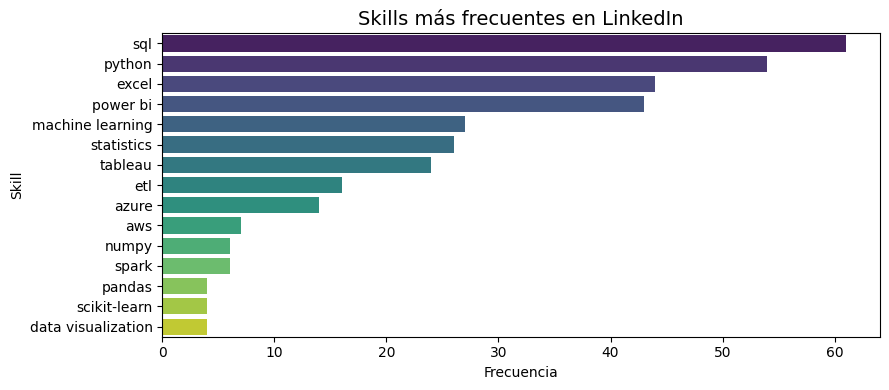

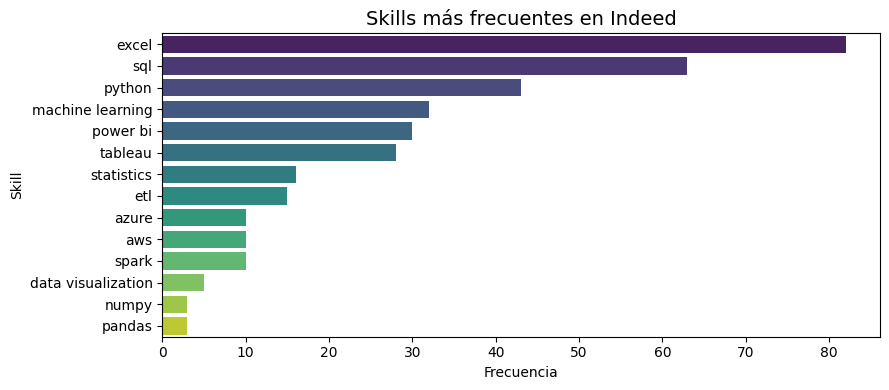

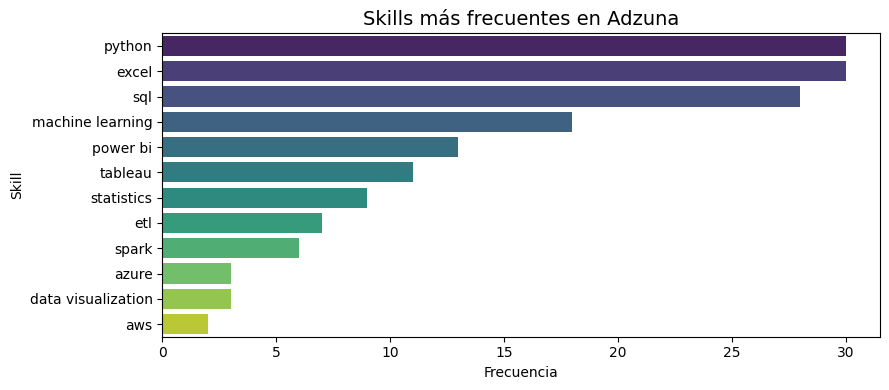

In [ ]:
# 4. Visualizar skills frecuentes
graficar_skills(df_linkedin_skills_inicial, "Skills más frecuentes en LinkedIn")
graficar_skills(df_indeed_skills_inicial, "Skills más frecuentes en Indeed")
graficar_skills(df_adzuna_skills_inicial, "Skills más frecuentes en Adzuna")


#### ⚠️<font color="red">El paso 5 de clasificacion o clustering no es realizable debido a la data reducida</font>, 
Esto se evidencia en los resultados de los topic-temas de Bertopic, por tal motivo se establece la estrategia de enfocar en los skill de los portales y los procesos de vectorizacion, modelling LDA y embedding en el analisis de las skills solicitadas en las ofertas laborales

#### Paso 6 - Extraer skills usando spaCy para mejorar la detección.
Ampliar el diccionario de skills y generación de matchers. 
Considerando especialmente: frases compuestas, variantes, normalización.  

In [123]:
# Ampliacion del diccionario de skills con más términos y categorías, para mejorar la detección de skills en los textos:
IDIOMAS = {
    "español": ["español", "spanish", "castellano", "espanyol", "espagnol"],
    "inglés": ["inglés", "english", "inglés b2", "inglés c1", "inglés avanzado", "anglès", "anglais"],
    "catalán": ["catalán", "catalan", "català"],  
    "francés": ["francés", "french", "francès", "français"],
    "alemán": ["alemán", "german", "alemany" ],
    "italiano": ["italiano", "italian", "italià"],
    "portugués": ["portugués", "portuguese", "portugues"],
}
SOFT_SKILLS = {
    "comunicación": ["comunicación", "communication", "comunicarse", "comunicació", "communication"],
    "trabajo en equipo": ["trabajo en equipo", "teamwork", "colaboración", "collaboration", "treball en equip", "travail d'équipe"],
    "liderazgo": ["liderazgo", "leadership", "lideratge", "direction"],
    "pensamiento crítico": ["pensamiento crítico", "critical thinking", "pensament crític", "pensée critique"],
    "resolución de problemas": ["resolución de problemas", "problem solving", "resolució de problemes", "résolution de problèmes"],
    "organización": ["organización", "organizational", "organizado", "organització", "organisation"],
    "proactividad": ["proactividad", "proactive", "proactivitat", "proactivité"],
    "adaptabilidad": ["adaptabilidad", "adaptable", "adaptability", "adaptabilitat", "adaptabilité"], 
    "gestión del tiempo": ["gestión del tiempo", "time management", "gestió del temps", "gestion du temps"],
    "orientación a resultados": ["orientación a resultados", "results oriented", "orientació a resultats", "orientation vers les résultats"],
}
HARD_SKILLS = {
    "python": ["python", "py"],
    "r": [" r ", " r,", " r.", "lenguaje r"],
    "sql": ["sql", "postgres", "postgresql", "mysql", "bigquery"],
    "excel": ["excel", "microsoft excel"],
    "estadística": ["estadística", "statistics", "statistical", "statistiques"],
    "data analysis": ["data analysis", "análisis de datos", "anàlisi de dades", "analyse des données"],
    "data visualization": ["data visualization", "visualización de datos", "visualització de dades", "visualisation des données"],
    "etl": ["etl", "extract transform load"],
}
BI_TOOLS = {
    "power bi": ["power bi", "powerbi", "power-bi"],
    "tableau": ["tableau"],
    "looker studio": ["looker", "looker studio", "google data studio"],
    "qlik": ["qlik", "qlikview", "qliksense"],
}
ML_AI = {
    "machine learning": ["machine learning", "ml"],
    "deep learning": ["deep learning", "dl"],
    "scikit-learn": ["scikit-learn", "sklearn"],
    "tensorflow": ["tensorflow"],
    "pytorch": ["pytorch"],
    "nlp": ["nlp", "procesamiento de lenguaje natural"],
}
DATA_ENGINEERING = {
    "spark": ["spark", "pyspark"],
    "hadoop": ["hadoop"],
    "airflow": ["airflow"],
    "kafka": ["kafka"],
    "docker": ["docker"],
    "kubernetes": ["kubernetes", "k8s"],
    "git": ["git", "github", "control de versiones"],
}
CLOUD = {
    "aws": ["aws", "amazon web services"],
    "azure": ["azure","azure cloud"],
    "gcp": ["gcp", "google cloud"],
    "databricks": ["databricks"],
    "snowflake": ["snowflake"],
}
FRAMEWORKS_LIBRERIAS = {
    "pandas": ["pandas"],
    "numpy": ["numpy"],
    "scikit-learn": ["scikit-learn", "sklearn"],
    "tensorflow": ["tensorflow"],
    "pytorch": ["pytorch"],
    "matplotlib": ["matplotlib"],
    "seaborn": ["seaborn"],
    "keras": ["keras"],
    "xgboost": ["xgboost"],
    "lightgbm": ["lightgbm", "lgbm"],
    "statsmodels": ["statsmodels"],
}
PROGRAMMING = {
    "backend": ["backend", "back-end"],
    "frontend": ["frontend", "front-end"],
    "fullstack": ["fullstack", "full-stack"],
    "api": ["api", "rest api", "restful api"],
    "rest": ["rest", "restful"],
    "microservicios": ["microservicios", "microservices", "microserveis"],
    "php": ["php"],
    "java": ["java"],
    "javascript": ["javascript", "js"],
    "typescript": ["typescript", "ts"],
    "node": ["node", "nodejs", "node.js"],
    "react": ["react", "reactjs", "react.js"],
    "angular": ["angular"],
    "django": ["django"],
    "flask": ["flask"],
    "fastapi": ["fastapi"],
}
DATA_ENGINEERING_EXTRA = {
    "redshift": ["redshift", "amazon redshift"],
    "warehouse": ["data warehouse", "warehouse"],
    "datalake": ["data lake", "datalake"],
    "dbt": ["dbt", "data build tool"],
    "sql server": ["sql server", "mssql"],
    "oracle": ["oracle"],
    "mariadb": ["mariadb"],
    "mongodb": ["mongodb", "mongo"],
    "redis": ["redis"],
}
DEVOPS = {
    "devops": ["devops"],
    "ci/cd": ["ci/cd", "cicd", "continuous integration", "continuous delivery"],
    "terraform": ["terraform"],
    "ansible": ["ansible"],
}
DATABASES_EXTRA = {
    "bbdd": ["bbdd", "bases de datos", "base de dades", "dataset", "base de données"],
    "sql server": ["sql server", "mssql"],
    "oracle": ["oracle"],
    "mariadb": ["mariadb"],
    "mongodb": ["mongodb", "mongo"],
    "redis": ["redis"],
}

DICCIONARIO_SKILLS = {
    **IDIOMAS,
    **SOFT_SKILLS,
    **HARD_SKILLS,
    **BI_TOOLS,
    **ML_AI,
    **DATA_ENGINEERING,
    **CLOUD,
    **FRAMEWORKS_LIBRERIAS,
    **PROGRAMMING,
    **DATA_ENGINEERING_EXTRA,
    **DEVOPS,
    **DATABASES_EXTRA
}


In [122]:
modelos = { "es": nlp_es, "ca": nlp_ca, "en": nlp_en, "fr": nlp_fr}

In [ ]:
# Función para detectar el idioma de un texto
def detectar_idioma_seguro(texto):
    lang = detectar_idioma(texto)
    if lang not in modelos:
        return "es"   # fallback
    return lang


In [ ]:
# Función para crear el matcher para cada idioma
def crear_matcher_idioma(diccionario, modelos):
    matchers_idioma = {}
    for idioma, nlp in modelos.items():
            matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
            for skill, variantes in diccionario.items():
                patrones = [nlp.make_doc(v.lower()) for v in variantes]
                matcher.add(skill, patrones)
            matchers_idioma[idioma] = matcher
            
    return matchers_idioma

matchers_idioma = crear_matcher_idioma(DICCIONARIO_SKILLS, modelos)


In [126]:
# Función para extraer skills GLOBALES usando spaCy y el matcher, 
# detectando el idioma y seleccionando el modelo adecuado
def extraer_skills_spacy(textos, modelos):
    skills_detectadas = []

    for texto in textos:
        idioma = detectar_idioma_seguro(texto)
        nlp = modelos[idioma]
        matcher = matchers_idioma[idioma]

        doc = nlp(texto)
        matches = matcher(doc)

        skills_en_texto = set()

        for match_id, start, end in matches:
            skill = doc.vocab.strings[match_id]
            skills_en_texto.add(skill)

        skills_detectadas.extend(list(skills_en_texto))

    return skills_detectadas


In [127]:
# Aplicar extracción avanzada de skills con spaCy
skills_linkedin = extraer_skills_spacy(df_LinkedIn["descripcion_nlp"], modelos)
skills_indeed = extraer_skills_spacy(df_Indeed["descripcion_nlp"], modelos)
skills_adzuna = extraer_skills_spacy(df_Adzuna["descripcion_nlp"], modelos)


In [62]:
# Función para extraer skills por oferta 
# detectando el idioma, usa el matcher y modelo adecuado
def extraer_skills_spacy_por_oferta(texto, modelos):
    idioma = detectar_idioma_seguro(texto)
    nlp = modelos[idioma]
    matcher = matchers_idioma[idioma]

    doc = nlp(texto)
    matches = matcher(doc)
    
    skills_en_texto = set()

    for match_id, start, end in matches:
        skill = doc.vocab.strings[match_id]
        skills_en_texto.add(skill)

    return list(skills_en_texto)


In [128]:
# Aplicar extracción avanzada de skills por ofertas de cada portal
df_LinkedIn["skills"] = df_LinkedIn["descripcion_nlp"].apply(lambda x: extraer_skills_spacy_por_oferta(x, modelos))
df_Indeed["skills"] = df_Indeed["descripcion_nlp"].apply(lambda x: extraer_skills_spacy_por_oferta(x, modelos))
df_Adzuna["skills"] = df_Adzuna["descripcion_nlp"].apply(lambda x: extraer_skills_spacy_por_oferta(x, modelos))


#### Paso 7 - Descubrir skills emergentes con embeddings
Skills emergentes: 
no están en diccionario, aparecen en las ofertas, son semánticamente cercanas a skills conocidas, y por tanto deberían considerarse.  
Ejemplos típicos: 
“Looker Studio”, “dbt”, “Databricks”, “Kubernetes”, “Snowflake”, “BigQuery”, “Power Query”, “Pyspark”, “Plotly”, “Dash”  
1. Obtener embeddings de todas las palabras relevantes del corpus
Usar modelo de embeddings (el mismo de BERTopic o un modelo de spaCy o el mismo de BERTopic - MiniLM).
2. Calcular la similitud entre cada palabra del corpus y cada skill del diccionario
Esto permite ver qué palabras están “cerca” de skills conocidas.
3. Filtrar palabras que NO están en el diccionario
Así obtener solo skills nuevas.
4. Filtrar por frecuencia mínima
Para evitar ruido (ej.: palabras que aparecen solo 1 vez).
5. Revisar manualmente las candidatas


In [ ]:
# Unimos todos los textos de los tres portales
todos_los_textos = list(df_LinkedIn["descripcion_nlp"]) + \
                    list(df_Indeed["descripcion_nlp"]) + \
                    list(df_Adzuna["descripcion_nlp"])

#### Paso 7A. Skill emergentes con spaCy

In [ ]:
# Función para obtener el vocabulario de los textos
def obtener_vocabulario_spacy(textos, nlp_es, nlp_en, nlp_ca):
    vocabulario = []

    for texto in textos:
        idioma = detectar_idioma(texto)

        # Selección del modelo según idioma
        if idioma == "es":
            doc = nlp_es(texto.lower())
        elif idioma == "en":
            doc = nlp_en(texto.lower())
        elif idioma == "ca":
            doc = nlp_ca(texto.lower())
        else:
            doc = nlp_es(texto.lower())  # fallback

        # Extraer vocabulario (lemmas)
        for token in doc:
            if token.is_alpha:
                vocabulario.append(token.lemma_)

    return vocabulario
# usa detectar_idioma

In [ ]:
# función para obtener embeddings de las palabras del vocabulario
def obtener_embeddings_vocab_spacy(vocabulario, nlp_es, nlp_en, nlp_ca):
    embeddings = {}

    for palabra in vocabulario:
        idioma = detectar_idioma(palabra)

        if idioma == "es":
            token = nlp_es(palabra)[0]
        elif idioma == "en":
            token = nlp_en(palabra)[0]
        elif idioma == "ca":
            token = nlp_ca(palabra)[0]
        else:
            token = nlp_es(palabra)[0]

        embeddings[palabra] = token.vector

    return embeddings
# usa detectar_idioma

In [ ]:
# Funcion para detectar skills emergentes usando embeddings y similitud coseno, 
# comparando el vocabulario del portal con las skills conocidas en el diccionario, detectando el idioma
def skills_emergentes_con_spacy(vocab_embeddings, diccionario, nlp_es, nlp_en, nlp_ca, umbral=0.65):
    emergentes = []

    # Embeddings de skills conocidas
    skills = list(diccionario.keys())
    skill_vectors = []

    for skill in skills:
        idioma_skill = detectar_idioma(skill)
        if idioma_skill == "es":
            token = nlp_es(skill)[0]
        elif idioma_skill == "en":
            token = nlp_en(skill)[0]
        elif idioma_skill == "ca":
            token = nlp_ca(skill)[0]
        else:
            token = nlp_es(skill)[0]
        skill_vectors.append(token.vector)

    skill_vectors = np.array(skill_vectors)

    # Comparar cada palabra del vocabulario con las skills conocidas
    for palabra, vector in vocab_embeddings.items():
        sim = cosine_similarity([vector], skill_vectors)[0]
        max_sim = sim.max()
        skill_cercana = skills[sim.argmax()]

        if palabra not in diccionario and max_sim > umbral:
            emergentes.append((palabra, skill_cercana, max_sim))

    return emergentes


In [ ]:
# Aplicarlo al corpus completo
vocabulario_spacy = obtener_vocabulario_spacy(todos_los_textos, nlp_es, nlp_en, nlp_ca)
embeddings_vocab_spacy = obtener_embeddings_vocab_spacy(vocabulario_spacy, nlp_es, nlp_en, nlp_ca)

skills_emergentes_spacy = skills_emergentes_con_spacy(embeddings_vocab_spacy, DICCIONARIO_SKILLS, nlp_es, nlp_en, nlp_ca)

In [97]:
# Ordenar por similitud
skills_emergentes_spacy_ord = sorted(skills_emergentes_spacy, key=lambda x: x[2], reverse=True)
print("Skills emergentes detectadas:")
for palabra, skill_cercana, similitud in skills_emergentes_spacy_ord[:60]:
    print(f"{palabra} (similar a {skill_cercana}, similitud: {similitud:.2f})")

Skills emergentes detectadas:
pensamiento (similar a pensamiento crítico, similitud: 1.00)
cx (similar a r, similitud: 1.00)
jd (similar a r, similitud: 1.00)
nube (similar a azure, similitud: 1.00)
iar (similar a r, similitud: 1.00)
rh (similar a r, similitud: 1.00)
ota (similar a r, similitud: 1.00)
rm (similar a r, similitud: 1.00)
fd (similar a r, similitud: 1.00)
data (similar a data analysis, similitud: 1.00)
power (similar a power bi, similitud: 1.00)
trabajo (similar a trabajo en equipo, similitud: 1.00)
motivación (similar a proactividad, similitud: 1.00)
level (similar a spark, similitud: 1.00)
stack (similar a python, similitud: 1.00)
dataset (similar a data analysis, similitud: 1.00)
teletrabajo (similar a trabajo en equipo, similitud: 1.00)
gi (similar a ci/cd, similitud: 1.00)
italy (similar a italiano, similitud: 1.00)
empower (similar a power bi, similitud: 1.00)
github (similar a python, similitud: 1.00)
database (similar a data analysis, similitud: 1.00)
datasets (sim

#### Paso 7B. Skill emergentes con MiniLM
SpaCy asigna vectores nulos o idénticos a palabras desconocidas, no está diseñado para similitud semántica profunda.
Se requiere otro modelo de embedding robusto se considera sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Este es un un modelo SBERT, multilingüe, ligero, rápido, muy bueno para similitud semántica, ideal para textos cortos (skills, palabras técnicas) el mismo que usa BERTopic para embeddings

In [55]:
# Cargar el modelo MiniLM
# Modelo multilingüe usado también en BERTopic
modelo = modelo_embeddings 


In [ ]:
# Función para obtener vocabulario
def obtener_vocabulario(textos, nlp_es, nlp_en, nlp_ca):
    vocabulario = []

    for texto in textos:
        idioma = detectar_idioma(texto)

        # Selección del modelo según idioma
        if idioma == "es":
            doc = nlp_es(texto.lower())
        elif idioma == "en":
            doc = nlp_en(texto.lower())
        elif idioma =="ca":
            doc = nlp_ca(texto.lower())
        else:
            doc = nlp_es(texto.lower())  # fallback

        # Extraer vocabulario (lemmas)
        for token in doc:
            if token.is_alpha:
                vocabulario.append(token.lemma_)

    return vocabulario
# usa detectar_idioma

In [ ]:
# Fucion para filtrar vocabulario y asi evitar ruido
def limpiar_vocabulario(vocabulario, textos, diccionario, frecuencia_min=3):
    # 1. Variantes y claves del diccionario
    variantes = {v.lower() for lista in diccionario.values() for v in lista}
    claves = {k.lower() for k in diccionario.keys()}

    # 2. Frecuencias
    todas_palabras = []
    for t in textos:
        idioma = detectar_idioma(t)
        # Selección del modelo según idioma
        if idioma == "es":
            doc = nlp_es(t.lower())
        elif idioma == "en":
            doc = nlp_en(t.lower())
        elif idioma =="ca":
            doc = nlp_ca(t.lower())
        else:
            doc = nlp_es(t.lower())  # fallback
        
        todas_palabras.extend([tok.text for tok in doc if tok.is_alpha])

    freq = Counter(todas_palabras)

    vocab_filtrado = []
    for palabra in vocabulario:
        if palabra in variantes or palabra in claves:
            continue
        if freq[palabra] < frecuencia_min:
            continue
        vocab_filtrado.append(palabra)

    return vocab_filtrado
# usa detectar_idioma

In [ ]:
# Funcion para obtener embeddings del vocabulario filtrado
def obtener_embeddings_MiniLM(vocabulario, modelo):
    emb_vocab = {}
    for palabra in vocabulario:
        emb_vocab[palabra] = modelo.encode(palabra)
    return emb_vocab


In [ ]:
# Funcion para obtener embeddings de las skills del diccionario
def embeddings_diccionario_MiniLM(diccionario, modelo):
    skills = list(diccionario.keys())
    skill_vectors = modelo.encode(skills)
    return skills, skill_vectors


In [ ]:
# Funciones para filtrar vocabulario
def filtrar_por_pos(palabras, nlp_es, nlp_en, nlp_ca):
    filtradas = []
    for palabra in palabras:
        idioma = detectar_idioma(palabra)
        if idioma == "es":
            doc = nlp_es(palabra)
        elif idioma == "en":
            doc = nlp_en(palabra)
        elif idioma =="ca":
            doc = nlp_ca(palabra)
        else:
            doc = nlp_es(palabra)

        token = doc[0]
        if token.pos_ in ["NOUN", "PROPN"] or palabra.isupper():
            filtradas.append(palabra)

    return filtradas
# usa detectar_idioma

def filtrar_por_frecuencia(palabras, textos, min_freq=3):
    conteo = Counter()

    for texto in textos:
        for palabra in palabras:
            if palabra in texto.lower():
                conteo[palabra] += 1

    return [p for p in palabras if conteo[p] >= min_freq]

def filtrar_por_longitud(palabras, min_len=3):
    return [p for p in palabras if len(p) >= min_len or p.isupper()]

STOPWORDS_EXTRA = {
    "detail", "detailed", "certain", "fully", "full", "level",
    "size", "quick", "depth", "advance", "sheet"
}

def filtrar_stopwords_extra(palabras):
    return [p for p in palabras if p.lower() not in STOPWORDS_EXTRA]

EMPRESAS = {"aizon", "accenture", "everis", "indra", "telefonica"}

def filtrar_empresas(palabras):
    return [p for p in palabras if p.lower() not in EMPRESAS]


In [ ]:
# Funcion con filtros avanzados
def filtrar_vocabulario_avanzado(vocabulario):
    vocab_filtrado = []

    # Lista blanca técnica (skills potenciales)
    whitelist = [
        "spark", "sql", "cloud", "azure", "aws", "gcp",
        "pyspark", "databricks", "snowflake", "bigquery",
        "dbt", "hive", "presto", "airflow", "kafka",
        "terraform", "jenkins", "docker", "kubernetes",
        "mlflow", "superset", "looker", "plotly", "dash",
        "power", "query", "etl", "ml", "ai"
    ]

    # Lista negra basada en tus resultados reales
    stopwords_custom = {
        "datos", "dataset", "això",
        "cuadro", "panda", "entidad", "marcha", "ganas", "renta",
        "time", "equipo", "ida", "dades", "dans", "sala", "adobe",
        "cena", "données", "pto", "saas", "ingesta", "ton", "cadena",
        "erp", "nyse", "resultado", "tiempo", "avance", "avec", "hora",
        "équipes", "vigilia", "konecta", "mettre", "chief", "equivalente",
        "undergo", "análisis", "alineación", "recurso", "campo", "vous",
        "despliegue", "solutions", "tendencia", "analysis", "scikit",
        "timeframe", "detalle", "acompañamiento", "empresas", "dir",
        "empresa"
    }

    for palabra in vocabulario:
        idioma = detectar_idioma(palabra)
        # Selección del modelo según idioma
        if idioma == "es":
            doc = nlp_es(palabra.lower())
        elif idioma == "en":
            doc = nlp_en(palabra.lower())
        elif idioma =="ca":
            doc = nlp_ca(palabra.lower())
        else:
            doc = nlp_es(palabra.lower())  # fallback

        token = doc[0]

        # 1. Solo sustantivos
        #if token.pos_ != "NOUN":
        #   continue

        # 2. Excluir entidades geográficas
        if token.ent_type_ in ["LOC", "GPE"]:
            continue

        # 3. Excluir palabras muy cortas
        if len(palabra) < 3:
            continue

        # 4. Excluir palabras comunes no-skills
        #if palabra in stopwords_custom:
        #    continue

        # 5. Permitir solo palabras que contengan patrones técnicos
        if not any(w in palabra.lower() for w in whitelist):
            continue

        vocab_filtrado.append(palabra)

    return vocab_filtrado
# usa detectar_idioma

In [ ]:
# Funcion para detectar skills emergentes y calcular similitud
def detectar_skills_emergentes_MiniLM(emb_vocab, skills, skill_vectors, umbral=0.70):
    emergentes = []

    for palabra, vector in emb_vocab.items():

        # ignorar ruido
        if len(palabra) < 3:
            continue

        sim = cosine_similarity([vector], skill_vectors)[0]
        max_sim = sim.max()
        skill_cercana = skills[sim.argmax()]

        if max_sim >= umbral:
            emergentes.append((palabra, skill_cercana, float(max_sim)))

    return emergentes


In [ ]:
# Pipeline con todos los pasos de NLP para obtener skills emergentes

# 1. Vocabulario bilingüe
vocabulario = obtener_vocabulario(todos_los_textos, nlp_es, nlp_en, nlp_ca, nlp_fr)

# 2. Limpiar vocabulario
vocab_filtrado_p1 = limpiar_vocabulario(vocabulario, todos_los_textos, DICCIONARIO_SKILLS)
vocab_filtrado_p2 = filtrar_vocabulario_avanzado(vocab_filtrado_p1)

# 2. Filtros avanzados
vocab_filtrado_p3 = filtrar_por_longitud(vocab_filtrado_p2)
vocab_filtrado_p4 = filtrar_stopwords_extra(vocab_filtrado_p3)
vocab_filtrado_p5 = filtrar_empresas(vocab_filtrado_p4)
vocab_filtrado_p6 = filtrar_por_pos(vocab_filtrado_p5, nlp_es, nlp_en, nlp_ca, nlp_fr)
vocab_filtrado_p7 = filtrar_por_frecuencia(vocab_filtrado_p6, todos_los_textos, min_freq=3)

# 4. Embeddings del vocabulario
emb_vocab_miniLM = obtener_embeddings_MiniLM(vocab_filtrado_p7, modelo_embeddings)

# 5. Embeddings del diccionario
skills_miniLM, skill_vectors_miniLM = embeddings_diccionario_MiniLM(DICCIONARIO_SKILLS, modelo_embeddings)

# 6. Skills emergentes
emergentes_miniLM = detectar_skills_emergentes_MiniLM(emb_vocab_miniLM, skills_miniLM, skill_vectors_miniLM, umbral=0.70)

# 7. Ordenar
emergentes_orden_miniLM = sorted(emergentes_miniLM, key=lambda x: x[2], reverse=True)


In [90]:
print("Skills emergentes detectadas:")
for palabra, skill_cercana, similitud in emergentes_orden_miniLM[:50]:
    print(f"{palabra} (similar a {skill_cercana}, similitud: {similitud:.2f})")

Skills emergentes detectadas:
uml (similar a java, similitud: 0.90)
air (similar a airflow, similitud: 0.85)
mlops (similar a java, similitud: 0.81)
liaise (similar a java, similitud: 0.78)
nosql (similar a sql, similitud: 0.78)
power (similar a power bi, similitud: 0.75)


⚠️<font color="orange">El diccionario contiene muchas skills asociadas a estos terminos identificados.</font>

Se exportaran los resultados obtenidos para continuar con el proceso de NLP para la extracción de requisitos. 

In [ ]:
# df de skills por portal global, proviene de la lista de skills_{portal}
df_skills_linkedin = pd.DataFrame(skills_linkedin, columns=['skill'])
df_skills_indeed = pd.DataFrame(skills_indeed, columns=['skill'])
df_skills_adzuna = pd.DataFrame(skills_adzuna, columns=['skill'])

In [ ]:
# exportar df con skills globales por portal
df_skills_linkedin.to_csv("df_linkedin_skills_global.csv", index=False)
df_skills_indeed.to_csv("df_indeed_skills_global.csv", index=False)
df_skills_adzuna.to_csv("df_adzuna_skills_global.csv", index=False)

In [ ]:
# Exportar df con skills por oferta para cada portal
df_LinkedIn.to_csv("df_LinkedIn_skills_ofertas.csv", index=False)
df_Indeed.to_csv("df_Indeed_skills_ofertas.csv", index=False)
df_Adzuna.to_csv("df_Adzuna_skills_ofertas.csv", index=False)